# VAC & blazarkit — Demo Notebook for the Spectroscopic Analysis of Fermi Detected blazars Using SDSS-V

This notebook demonstrates how to use **blazarkit** to explore the Fermi/SDSS-V
Blazar Value-Added Catalogue (VAC) and visualise the pre-computed spectral
fitting results for individual sources.

We follow a natural workflow:
1. Load the VAC and explore the sample properties
2. Select sources of interest using VAC columns
3. Load the full spectral fitting results for those sources using blazarkit
4. Visualise and analyse the spectral decomposition

---

### Before you start
Install blazarkit: 
```bash
pip install git+https://github.com/minlowie/Blazar-Analysis-Pipeline.git
```
You need this installation for the blazarkit analysis, described later in this tutorial 
### Reference
Nlowie et al. (in prep.) — *Optical Spectroscopic Analysis of Fermi Detected Blazars using SDSS-V*

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits
%matplotlib inline

---
# Part 1: Exploring the VAC

The Value-Added Catalogue (VAC) contains one row per source with tabulated
parameters from the spectral fitting pipeline. It is the starting point for
any analysis — use it to understand the sample, filter sources by properties,
and identify the SDSS_ID and MJD values needed to load individual sources
into blazarkit.

## 1. Load the VAC

The VAC is available through the SDSS SAS upon publication of SDSS-V DR20.
You can access it programmatically via`sdss_access` or using the 
VAC file if you have it locally as shown below.

The key columns for linking to blazarkit are `SDSS_ID` and `MJD`.

In [35]:
# # Option 1 — Load via sdss_access (recommnded when DR20 is public)
# import sdss_access
# import sdss_access.path

# sdss_path = sdss_access.path.Path(release='dr20', verbose=True)
# access    = sdss_access.Access(release='dr20', verbose=True)
# #Keyword is fermi_blazar_redshifts
# vac_file  = sdss_path.full('fermi_blazar_redshifts', v_vac='1.0.0')  

# if not sdss_path.exists('', full=vac_file):
#     # If the VAC file does not exist locally, download it from the SDSS server
#     access.remote()
#     access.add('fermi_blazar_redshifts', v_vac='1.0.0')
#     access.set_stream()
#     access.commit()
#     vac_file  = sdss_path.full('fermi_blazar_redshifts', v_vac='1.0.0')
# vac = Table.read(vac_file)

# print(f'VAC loaded: {len(vac)} sources')
# print(f'\nColumns: {vac.colnames}')

#Option 2 — Load a local copy (use this until DR20 is public)
vac = Table(fits.open('fermi_blazar_vac_dr20.fits')[1].data)
print(f'VAC loaded: {len(vac)} sources')
print(f'\nColumns: {vac.colnames}')

VAC loaded: 707 sources

Columns: ['SDSS_ID', 'SDSS_NAME', 'FGL_NAME', 'FGL_CLASS', 'BEST_MODEL', 'SDSS_CLASS', 'Z_SDSS', 'Z_fit', 'Z_fit_err', 'rchi2_fit', 'rchi2_sdss', 'Jet_Fraction', 'PL_alpha', 'PL_delta', 'SNR']


## 2. Sample breakdown

Let us start by understanding the composition of the sample — how many sources
belong to each best-fit model family and each Fermi classification.

In [36]:
from collections import Counter

print(f"{'Model':<25} {'N':>5}  {'%':>6}")
print('-' * 40)
for model, n in sorted(Counter(vac['BEST_MODEL']).items(), key=lambda x: -x[1]):
    print(f"  {model:<23} {n:>5}  {100*n/len(vac):>5.1f}%")

print(f"\n{'FGL Class':<15} {'N':>5}  {'%':>6}")
print('-' * 30)
for cls, n in sorted(Counter(vac['FGL_CLASS']).items(), key=lambda x: -x[1]):
    print(f"  {cls:<13} {n:>5}  {100*n/len(vac):>5.1f}%")

Model                         N       %
----------------------------------------
  Powerlaw+Galaxy           414   58.6%
  Powerlaw+Lines (High EW Line)    69    9.8%
  Powerlaw+Lines (Median Line)    57    8.1%
  Powerlaw+Lines (High Blueshift Line)    31    4.4%
  Powerlaw+QSO (Red z=0.5 (ebv = 0.2))    23    3.3%
  Powerlaw+QSO (High Blueshift z=0.2)    17    2.4%
  Powerlaw+QSO (High EW z=1.5)    16    2.3%
  Powerlaw+QSO (High EW z=0.2)    15    2.1%
  Powerlaw+QSO (Red z =0.5 (ebv = 0.1))    12    1.7%
  Powerlaw+QSO (High Blueshift z=1.5)    10    1.4%
  Powerlaw+QSO (Default z=1.5)     8    1.1%
  Galaxy                      7    1.0%
  Powerlaw+QSO (Default z=0.2)     7    1.0%
  Powerlaw                    7    1.0%
  QSO (High EW z=1.5)         4    0.6%
  QSO (Default z=0.2)         2    0.3%
  QSO (High Blueshift z=1.5)     2    0.3%
  QSO (Red z =0.5 (ebv = 0.1))     2    0.3%
  QSO (Red z=0.5 (ebv = 0.2))     2    0.3%
  QSO (Default z=1.5)         2    0.3%

FGL Class  

## 3. Population plots from the VAC

The VAC columns alone are sufficient for population-level analysis.
Here we plot the redshift and jet fraction distributions, and the
power-law slope distribution — all directly from the tabulated parameters.

We separate BL Lac candidates (PL+Galaxy or Powerlaw best model) from
FSRQ candidates (PL+QSO or PL+Lines) and apply a S/N >= 3 quality cut.

In [37]:
# Define masks
bl_mask   = np.array(['Powerlaw+Galaxy' in m or m == 'Powerlaw'
                       for m in vac['BEST_MODEL']])
fsrq_mask = np.array(['Powerlaw+QSO' in m or 'Powerlaw+Lines' in m
                       for m in vac['BEST_MODEL']])

z_vals    = np.array(vac['Z_fit'],        dtype=float)
jet_vals  = np.array(vac['Jet_Fraction'], dtype=float)
alpha_vals= np.array(vac['PL_alpha'],     dtype=float)
sn_vals   = np.array(vac['SNR'],          dtype=float)
sn_mask   = sn_vals >= 3

print(f'BL Lac candidates (S/N>=3):  {np.sum(bl_mask & sn_mask)}')
print(f'FSRQ candidates  (S/N>=3):  {np.sum(fsrq_mask & sn_mask)}')

BL Lac candidates (S/N>=3):  376
FSRQ candidates  (S/N>=3):  211


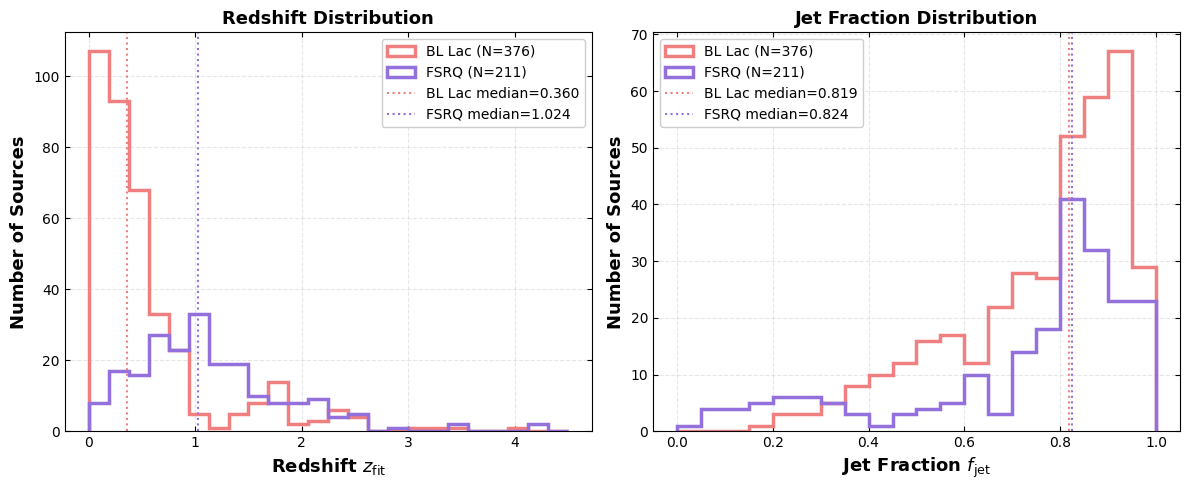

In [38]:
# Redshift and jet fraction distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

bins_z   = np.linspace(0, 4.5, 25)
bins_jet = np.linspace(0, 1, 21)

for ax, vals, bins, xlabel, title in [
    (ax1, z_vals,   bins_z,   r'Redshift $z_{\rm fit}$',      'Redshift Distribution'),
    (ax2, jet_vals, bins_jet, r'Jet Fraction $f_{\rm jet}$',  'Jet Fraction Distribution'),
]:
    ax.hist(vals[bl_mask & sn_mask], bins=bins, histtype='step',
            color='lightcoral', lw=2.5,
            label=f'BL Lac (N={np.sum(bl_mask & sn_mask)})')
    ax.hist(vals[fsrq_mask & sn_mask], bins=bins, histtype='step',
            color='mediumpurple', lw=2.5,
            label=f'FSRQ (N={np.sum(fsrq_mask & sn_mask)})')
    ax.axvline(np.nanmedian(vals[bl_mask & sn_mask]),
               color='lightcoral', ls=':', lw=1.5,
               label=f'BL Lac median={np.nanmedian(vals[bl_mask & sn_mask]):.3f}')
    ax.axvline(np.nanmedian(vals[fsrq_mask & sn_mask]),
               color='mediumpurple', ls=':', lw=1.5,
               label=f'FSRQ median={np.nanmedian(vals[fsrq_mask & sn_mask]):.3f}')
    ax.set_xlabel(xlabel, fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Sources', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, framealpha=0.95)
    ax.grid(alpha=0.3, linestyle='--')
    ax.tick_params(direction='in', top=True, right=True)

plt.tight_layout()
plt.show()

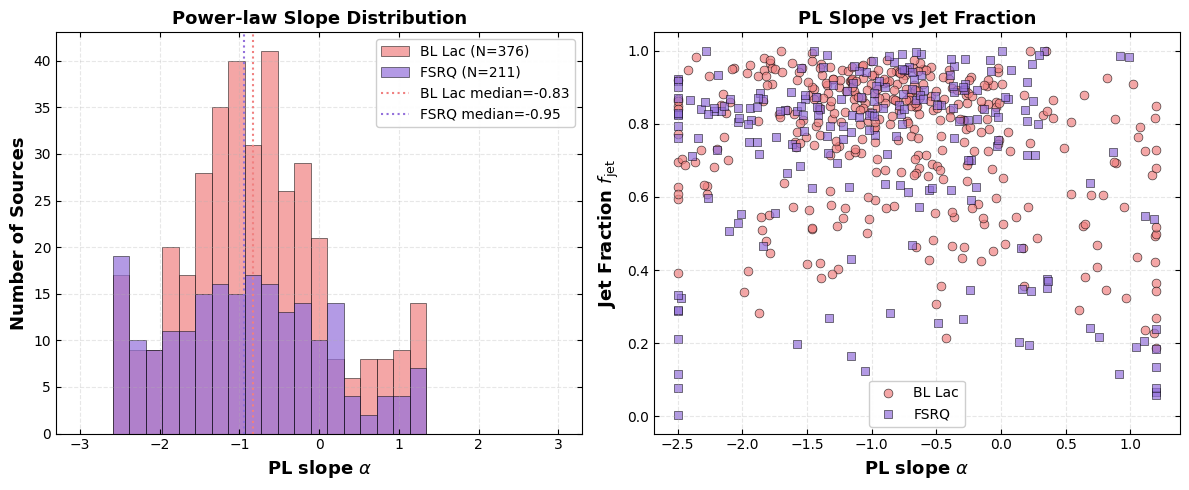

In [39]:
# Power-law slope distribution
finite_mask = np.isfinite(alpha_vals)
bins_alpha  = np.linspace(-3, 3, 30)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — histogram
axes[0].hist(alpha_vals[bl_mask & sn_mask & finite_mask], bins=bins_alpha,
             color='lightcoral', alpha=0.7, edgecolor='black', linewidth=0.5,
             label=f'BL Lac (N={np.sum(bl_mask & sn_mask & finite_mask)})')
axes[0].hist(alpha_vals[fsrq_mask & sn_mask & finite_mask], bins=bins_alpha,
             color='mediumpurple', alpha=0.7, edgecolor='black', linewidth=0.5,
             label=f'FSRQ (N={np.sum(fsrq_mask & sn_mask & finite_mask)})')
axes[0].axvline(np.nanmedian(alpha_vals[bl_mask & sn_mask & finite_mask]),
                color='lightcoral', ls=':', lw=1.5,
                label=f'BL Lac median={np.nanmedian(alpha_vals[bl_mask & sn_mask & finite_mask]):.2f}')
axes[0].axvline(np.nanmedian(alpha_vals[fsrq_mask & sn_mask & finite_mask]),
                color='mediumpurple', ls=':', lw=1.5,
                label=f'FSRQ median={np.nanmedian(alpha_vals[fsrq_mask & sn_mask & finite_mask]):.2f}')
axes[0].set_xlabel(r'PL slope $\alpha$', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Sources', fontsize=13, fontweight='bold')
axes[0].set_title('Power-law Slope Distribution', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10, framealpha=0.95)
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].tick_params(direction='in', top=True, right=True)

# Right — alpha vs jet fraction scatter
axes[1].scatter(alpha_vals[bl_mask & sn_mask & finite_mask],
                jet_vals[bl_mask & sn_mask & finite_mask],
                color='lightcoral', s=40, alpha=0.7, label='BL Lac',
                edgecolors='black', linewidths=0.5)
axes[1].scatter(alpha_vals[fsrq_mask & sn_mask & finite_mask],
                jet_vals[fsrq_mask & sn_mask & finite_mask],
                color='mediumpurple', s=40, alpha=0.7, label='FSRQ',
                edgecolors='black', linewidths=0.5, marker='s')
axes[1].set_xlabel(r'PL slope $\alpha$', fontsize=13, fontweight='bold')
axes[1].set_ylabel(r'Jet Fraction $f_{\rm jet}$', fontsize=13, fontweight='bold')
axes[1].set_title('PL Slope vs Jet Fraction', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10, framealpha=0.95)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].tick_params(direction='in', top=True, right=True)

plt.tight_layout()
plt.show()

## 4. Selecting sources of interest

The VAC columns let you filter the sample to find sources.
Below we select high S/N BL Lac candidates at
reliable redshifts — a good starting point for detailed inspection ):.

The `SDSS_ID` and `MJD` columns are what you need to pass to blazarkit.

In [40]:
# Select high S/N BL Lac candidates with reliable redshifts
select_mask = (bl_mask & sn_mask &
               np.isfinite(z_vals) & (z_vals > 0.05) & (z_vals < 1.8))

vac_sel = vac[select_mask]
vac_sel.sort('SNR')
vac_sel.reverse()

print(f'Selected {len(vac_sel)} BL Lac candidates with S/N>=3 and 0.05 < z < 1.8')
print(f'\nTop 5 by S/N:')
for row in vac_sel[:5]:
    mjd_val = row['MJD'] if 'MJD' in vac.colnames else 'N/A'
    print(f"  SDSS_ID={row['SDSS_ID']}  MJD={mjd_val}  "
          f"z={row['Z_fit']:.3f}  S/N={row['SNR']:.1f}  "
          f"f_jet={row['Jet_Fraction']:.2f}  Model={row['BEST_MODEL']}")

Selected 337 BL Lac candidates with S/N>=3 and 0.05 < z < 1.8

Top 5 by S/N:
  SDSS_ID=80861309  MJD=N/A  z=0.183  S/N=54.1  f_jet=0.87  Model=Powerlaw+Galaxy
  SDSS_ID=56366226  MJD=N/A  z=0.426  S/N=49.3  f_jet=0.94  Model=Powerlaw+Galaxy
  SDSS_ID=92558683  MJD=N/A  z=0.270  S/N=48.0  f_jet=0.85  Model=Powerlaw+Galaxy
  SDSS_ID=79079649  MJD=N/A  z=0.259  S/N=43.6  f_jet=0.92  Model=Powerlaw+Galaxy
  SDSS_ID=95998275  MJD=N/A  z=0.138  S/N=40.4  f_jet=0.67  Model=Powerlaw+Galaxy


---
# Part 2: Spectral Analysis with blazarkit

Now that we have identified sources of interest from the VAC, we load their
full pre-computed spectral fitting results using `NAKBlaZarCache`. This gives
access to the complete spectral decomposition — the observed spectrum, all
model fits, component contributions, redshift posteriors, and equivalent
width measurements.

You can also call a source directly if you already know its SDSS_ID and MJD
without going through the VAC.

## 5. Initialise the cache

### 
5.1 Import blazarkit and accessories 

In [41]:
# Reload blazarkit to ensure the latest version is used
import importlib
import blazarkit
importlib.reload(blazarkit)

## Import the necessary functions from blazarkit
from blazarkit import (
    NAKBlaZarCache,
    bz_inspect,
    bz_classify,
    bz_lines,
    bz_population,
    measure_ew,
    normalize_shape,
    get_redshift_peaks,
)

print('blazarkit imported successfully.')

blazarkit imported successfully.


### 
5.2 `NAKBlaZarCache` manages access to the pre-computed results. On first access
it streams each source file automatically and saves it locally — no account
or authentication required. All subsequent calls load instantly from local
storage.

In [42]:
# Initialise — streams automatically, saves to blazar_cache/
cache = NAKBlaZarCache()

# Or point to an existing local folder:
# cache = NAKBlaZarCache(cache_dir='/path/to/your/cache')

cached_files = cache.list_cached_objects()
# Output: 'Found 0 cached objects' on first run — expected.
# Files appear here after you load sources for the first time. 

Found 3 cached objects in blazar_cache/


## 6. Load a source

We use SDSS_ID and MJD to load a source — these can come from the VAC
or you can specify them directly. Here we use one of our test sources.

The results dictionary contains everything from the fitting pipeline:
metadata, spectrum, chi2 grids, redshift posteriors, best-fit parameters,
component contributions, and equivalent width measurements.

In [15]:
SDSS_ID = '20570296'
MJD     = 60027

results = cache.load(SDSS_ID, mjd=MJD)

# Print a full summary
meta  = results['metadata']
lmfit = results['lmfit_results']
comp  = results['components']

print(f"\n{'='*55}")
print(f"SDSS_ID:       {meta['SDSS_ID']}")
print(f"Fermi class:   {meta['fermi_class']}")
print(f"SDSS class:    {meta['obj_class']}")
print(f"S/N:           {meta['sn_median']:.1f}")
print(f"{'─'*55}")
print(f"Best model:    {lmfit['best_label']}")
print(f"z_fit:         {lmfit['z_best']:.4f}")
print(f"z_SDSS:        {meta['z_sdss']}")
print(f"AICc margin:   {lmfit['aicc_margin']:.1f}")
print(f"PL alpha:      {lmfit['pl_alpha']:.4f}")
print(f"PL delta:      {lmfit['pl_delta']:.4f}")
print(f"{'='*55}")

Loaded: obj_20570296_60027.pkl.gz

SDSS_ID:       20570296
Fermi class:   fsrq
SDSS class:    QSO
S/N:           10.5
───────────────────────────────────────────────────────
Best model:    Powerlaw+Lines (High Blueshift Line)
z_fit:         0.9961
z_SDSS:        0.9996569156646729
AICc margin:   49.0
PL alpha:      -1.2969
PL delta:      -1.2000


## 7. Spectral decomposition plot

`bz_inspect` is the main plotting function. It requires the `model` parameter:
- `model='best'` — shows only the best-fit model (most common use)
- `model='all'` — overlays all six model fits for comparison
- `model=[...]` — shows a specific combination

By default it shows the spectrum only. Pass `show_fig1=True` to also
see the χ²(z) and p(z) diagnostic figure.

  C III          : EW = -20.52 ±  1.34 Å, SNR = 15.3
  Mg II          : EW = -18.37 ±  0.90 Å, SNR = 20.5
  [O II]         : EW =  -2.40 ±  0.64 Å, SNR =  3.7
  H_beta         : EW = -25.53 ±  2.20 Å, SNR = 11.6
  [O III]        : EW =  -5.80 ±  1.56 Å, SNR =  3.7
  Ca II K        : EW =   2.94 ±  0.84 Å, SNR =  3.5
  Ca I G         : EW =   2.50 ±  0.41 Å, SNR =  6.0


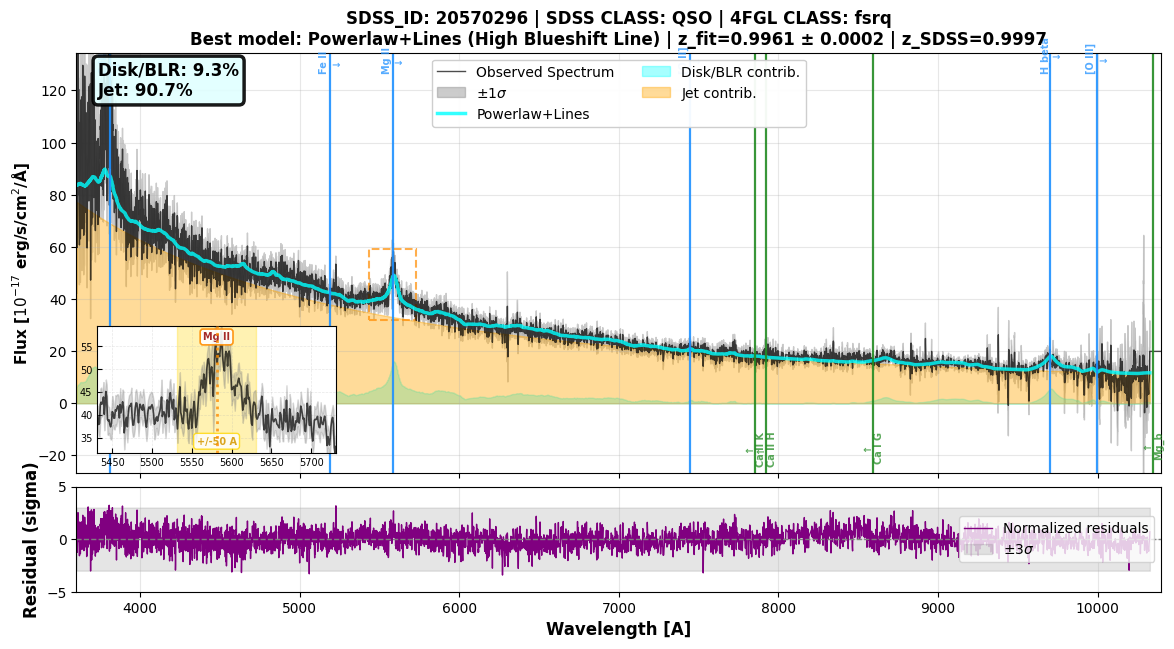


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [16]:
spec = bz_inspect(results, model='best')

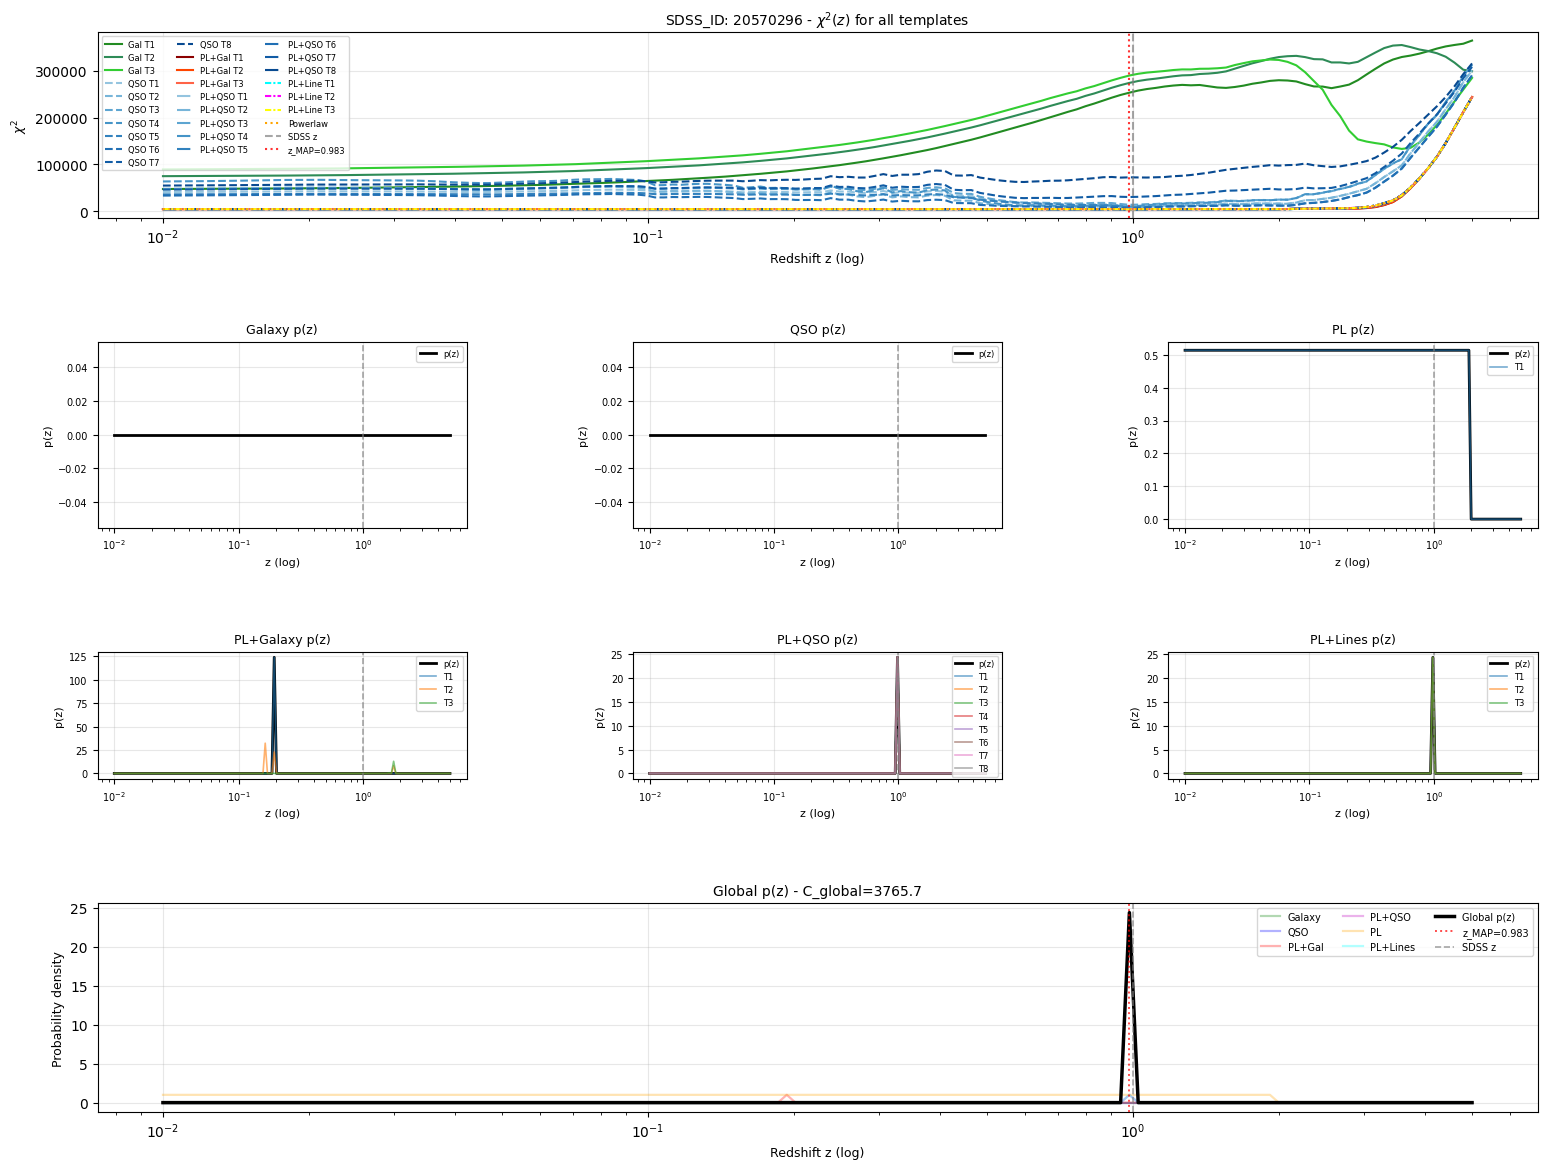

  C III          : EW = -20.52 ±  1.34 Å, SNR = 15.3
  Mg II          : EW = -18.37 ±  0.90 Å, SNR = 20.5
  [O II]         : EW =  -2.40 ±  0.64 Å, SNR =  3.7
  H_beta         : EW = -25.53 ±  2.20 Å, SNR = 11.6
  [O III]        : EW =  -5.80 ±  1.56 Å, SNR =  3.7
  Ca II K        : EW =   2.94 ±  0.84 Å, SNR =  3.5
  Ca I G         : EW =   2.50 ±  0.41 Å, SNR =  6.0


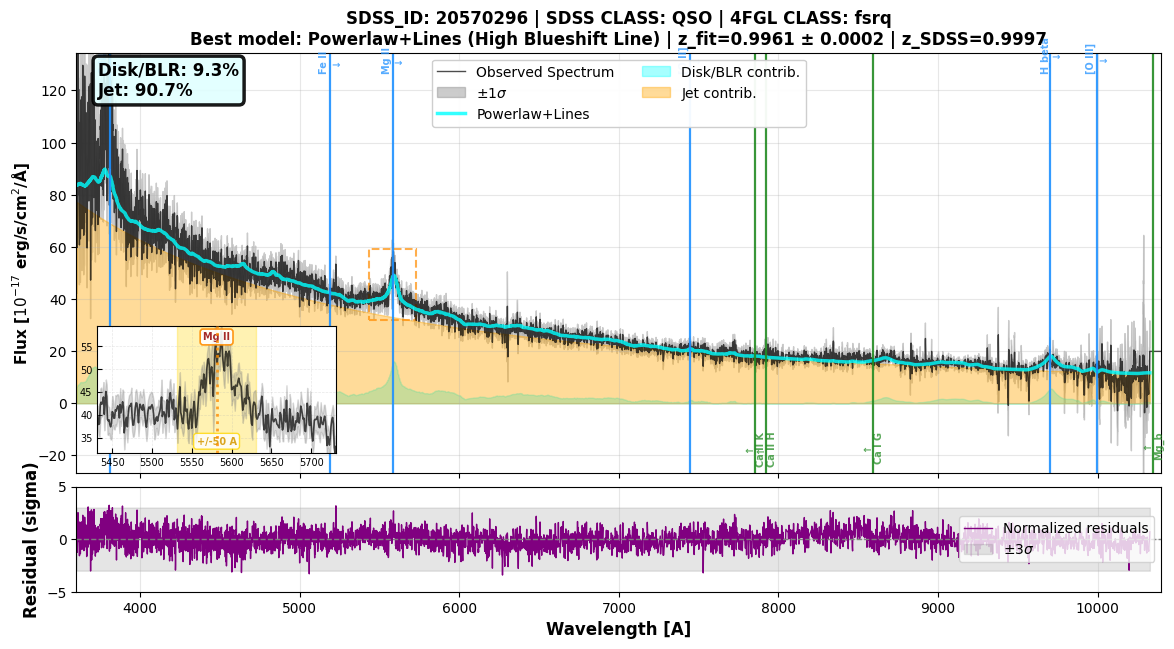


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [19]:
# Also show the chi2/p(z) diagnostic figure
spec = bz_inspect(results, model='best', posterior=True)

## 8. Customising the plot

All panels are individually controllable. Here are the most useful combinations.

  C III          : EW = -20.52 ±  1.34 Å, SNR = 15.3
  Mg II          : EW = -18.37 ±  0.90 Å, SNR = 20.5
  [O II]         : EW =  -2.40 ±  0.64 Å, SNR =  3.7
  H_beta         : EW = -25.53 ±  2.20 Å, SNR = 11.6
  [O III]        : EW =  -5.80 ±  1.56 Å, SNR =  3.7
  Ca II K        : EW =   2.94 ±  0.84 Å, SNR =  3.5
  Ca I G         : EW =   2.50 ±  0.41 Å, SNR =  6.0


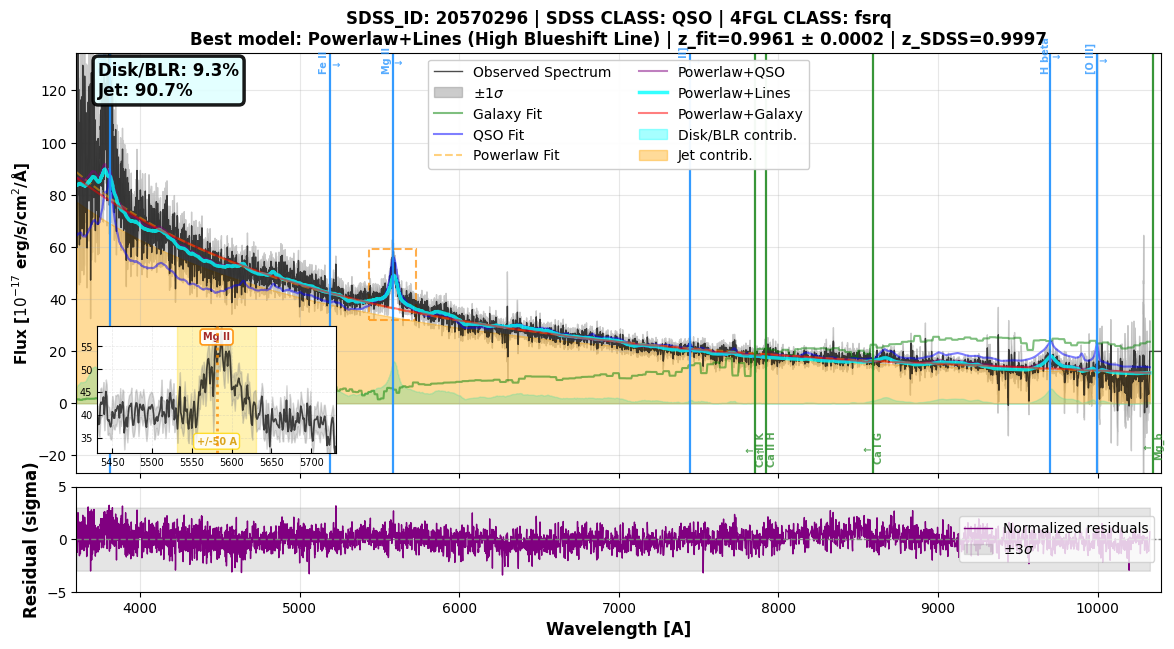


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [21]:
# All models overlaid — useful for comparing fits
spec = bz_inspect(results, model='all')

  C III          : EW = -20.52 ±  1.34 Å, SNR = 15.3
  Mg II          : EW = -18.37 ±  0.90 Å, SNR = 20.5
  [O II]         : EW =  -2.40 ±  0.64 Å, SNR =  3.7
  H_beta         : EW = -25.53 ±  2.20 Å, SNR = 11.6
  [O III]        : EW =  -5.80 ±  1.56 Å, SNR =  3.7
  Ca II K        : EW =   2.94 ±  0.84 Å, SNR =  3.5
  Ca I G         : EW =   2.50 ±  0.41 Å, SNR =  6.0


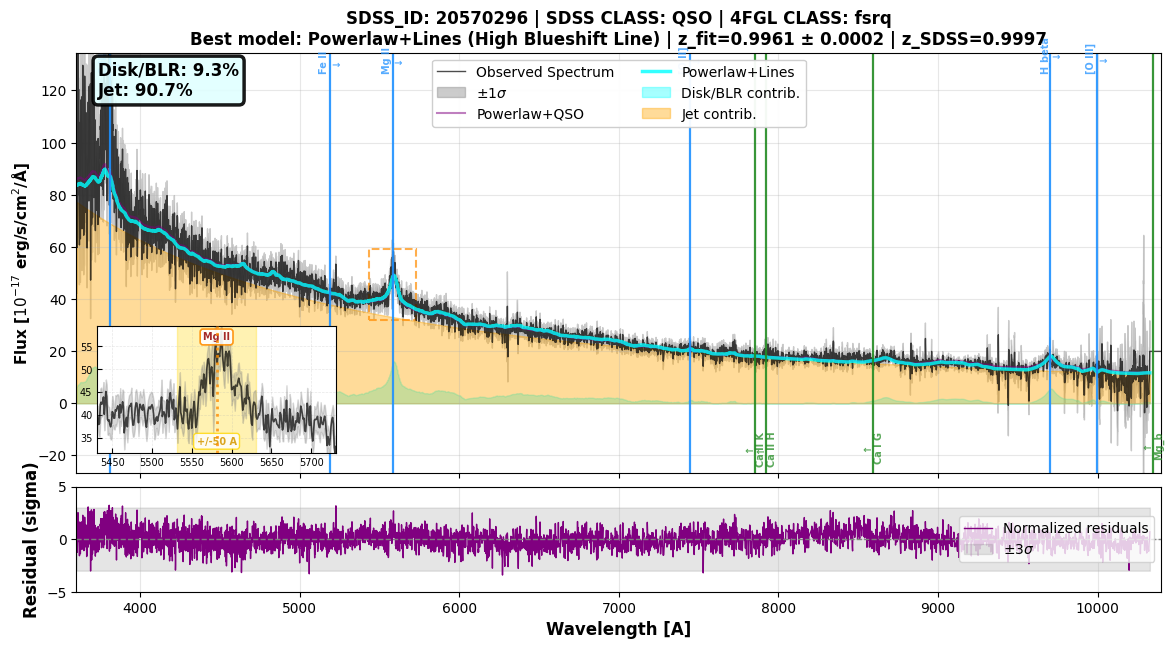


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [23]:
# Specific models only
spec = bz_inspect(results, model=['best', 'Powerlaw+QSO'])

  C III          : EW = -20.52 ±  1.34 Å, SNR = 15.3
  Mg II          : EW = -18.37 ±  0.90 Å, SNR = 20.5
  [O II]         : EW =  -2.40 ±  0.64 Å, SNR =  3.7
  H_beta         : EW = -25.53 ±  2.20 Å, SNR = 11.6
  [O III]        : EW =  -5.80 ±  1.56 Å, SNR =  3.7
  Ca II K        : EW =   2.94 ±  0.84 Å, SNR =  3.5
  Ca I G         : EW =   2.50 ±  0.41 Å, SNR =  6.0


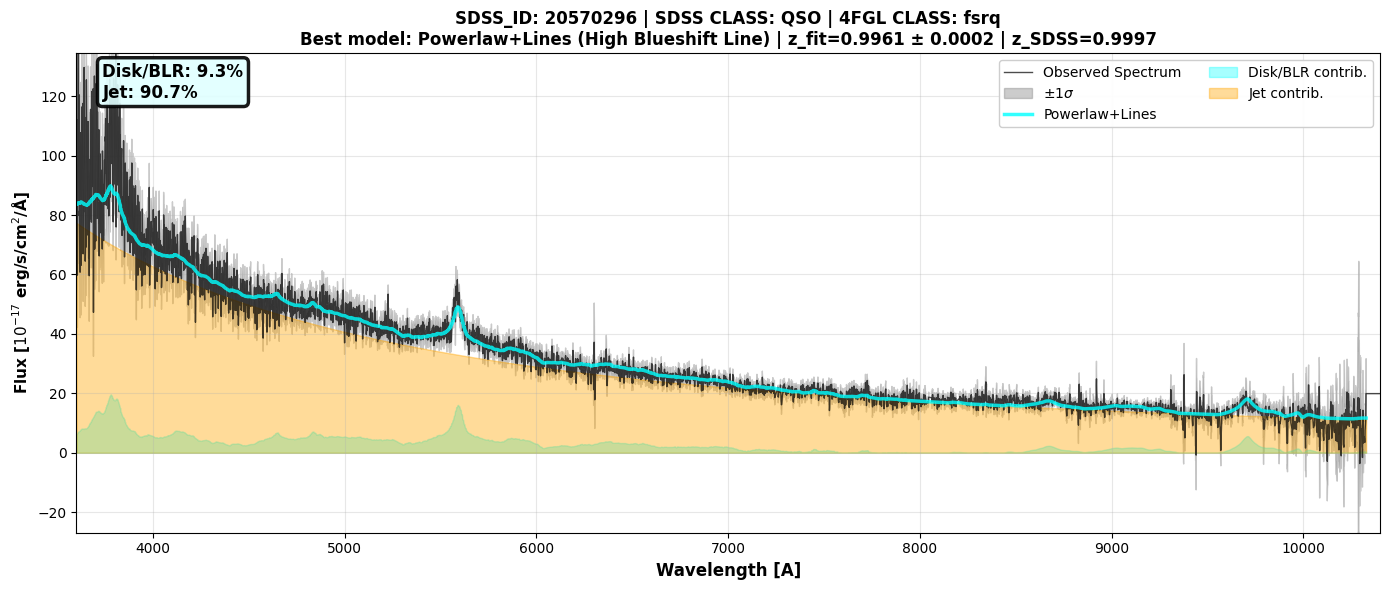


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [65]:
# Minimal clean plot
_, fig2 = bz_inspect(results, model='best',
                      show_inset=False,
                      show_line_markers=False,
                      show_residuals=False)

  C III          : EW = -20.52 ±  1.34 Å, SNR = 15.3
  Mg II          : EW = -18.37 ±  0.90 Å, SNR = 20.5
  [O II]         : EW =  -2.40 ±  0.64 Å, SNR =  3.7
  H_beta         : EW = -25.53 ±  2.20 Å, SNR = 11.6
  [O III]        : EW =  -5.80 ±  1.56 Å, SNR =  3.7
  Ca II K        : EW =   2.94 ±  0.84 Å, SNR =  3.5
  Ca I G         : EW =   2.50 ±  0.41 Å, SNR =  6.0


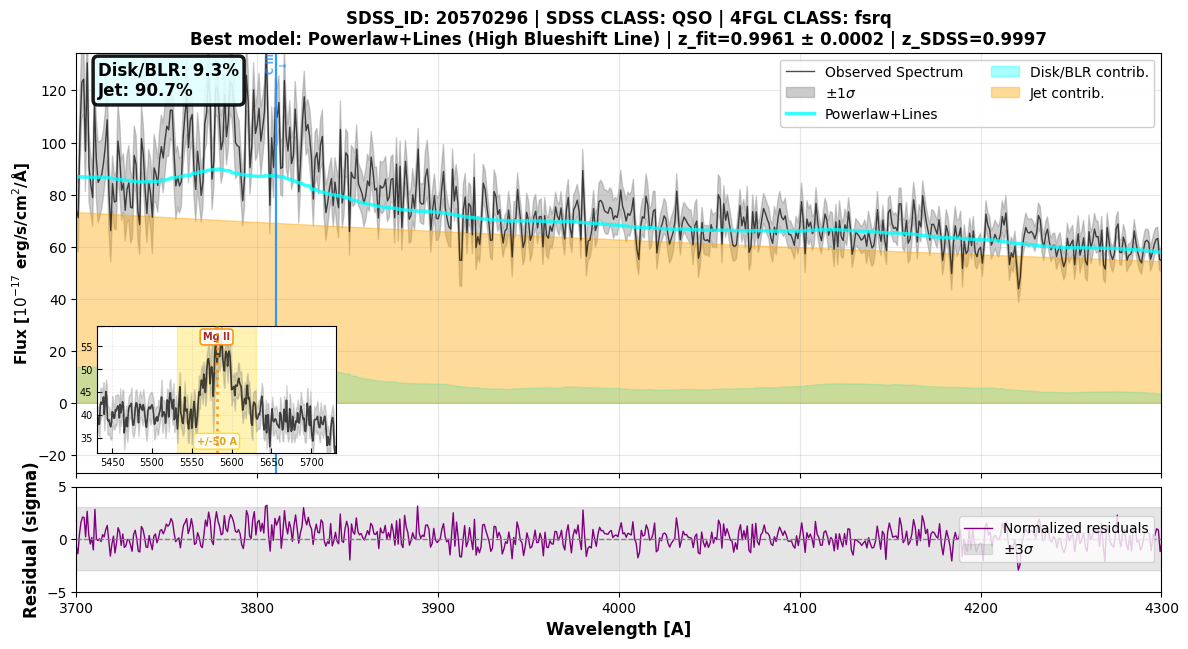


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [25]:
# Zoom into specific wavelength range
spec = bz_inspect(results, model='best', wavelength_range=(3700, 4300))

  C III          : EW = -20.52 ±  1.34 Å, SNR = 15.3
  Mg II          : EW = -18.37 ±  0.90 Å, SNR = 20.5
  [O II]         : EW =  -2.40 ±  0.64 Å, SNR =  3.7
  H_beta         : EW = -25.53 ±  2.20 Å, SNR = 11.6
  [O III]        : EW =  -5.80 ±  1.56 Å, SNR =  3.7
  Ca II K        : EW =   2.94 ±  0.84 Å, SNR =  3.5
  Ca I G         : EW =   2.50 ±  0.41 Å, SNR =  6.0


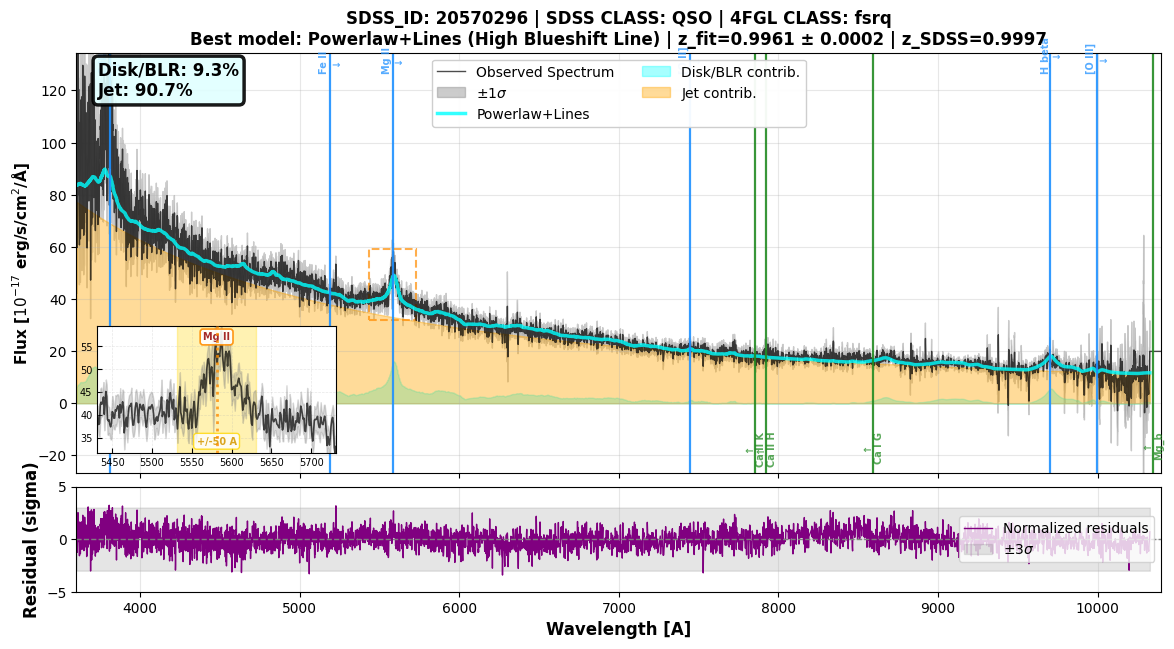

Saved: my_plots/20570296.pdf

SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [26]:
# Save to PDF - Creates a folder called 'my_plots' in the current working directory
spec = bz_inspect(results, model='best', save_dir = 'my_plots') 

## 9. Classification summary

`bz_classify` prints a one-line human-readable description of the source —
its blazar class, jet fraction, S/N, and key detected spectral lines.
Useful for quickly understanding a source without looking at the plots.

In [27]:
summary = bz_classify(results) 


SDSS_ID: 20570296 | Fermi: fsrq | SDSS: QSO
----------------------------------------------------------------------
FSRQ candidate at z=0.9961 | Jet-dominated (90.7%) | Emission lines only | S/N=10.5 | C III (emi, S/N=15.3) | Mg II (emi, S/N=20.5) | [O II] (emi, S/N=3.7)



## 10. Equivalent width measurements

`measure_ew` measures equivalent widths for 16 emission and absorption
features using adaptive window selection. A line is detected if S/N >= 3.
Positive EW = absorption, negative EW = emission.

In [28]:
spec   = results['spectrum']
z_best = results['lmfit_results']['z_best']

results_ew = measure_ew(
    spec['common_wave'], spec['flux_resamp'],
    spec['err_resamp'],  spec['fit_mask'], z_best
)

print(f"Equivalent widths at z = {z_best:.4f}:")
print(f"\n{'Line':<15} {'Type':<12} {'EW (A)':>10} {'±err':>8} {'S/N':>8} {'Det':>5}")
print('-' * 60)
for name, obs, ew, ew_err, snr, detected, ltype, window in results_ew:
    if np.isfinite(ew):
        flag = '✓' if detected else ''
        print(f"{name:<15} {ltype:<12} {ew:>10.2f} {ew_err:>8.2f} {snr:>8.1f} {flag:>5}")

Equivalent widths at z = 0.9961:

Line            Type             EW (A)     ±err      S/N   Det
------------------------------------------------------------
C III           emission         -20.52     1.34     15.3     ✓
Fe II           emission           1.25     0.45      2.7      
Mg II           emission         -18.37     0.90     20.5     ✓
[O II]          emission          -2.40     0.64      3.7     ✓
H_beta          emission         -25.53     2.20     11.6     ✓
[O III]         emission          -5.80     1.56      3.7     ✓
Ca II K         absorption         2.94     0.84      3.5     ✓
Ca II H         absorption        -2.45     0.87      2.8      
Ca I G          absorption         2.50     0.41      6.0     ✓
Mg_b            absorption         3.32     2.08      1.6      


## 11. EW summary plot

`bz_lines` produces a visual summary of all detected spectral lines.
Blue = emission lines, green = absorption lines.
The red dashed line marks the |EW| = 5 Å BL Lac/FSRQ boundary.

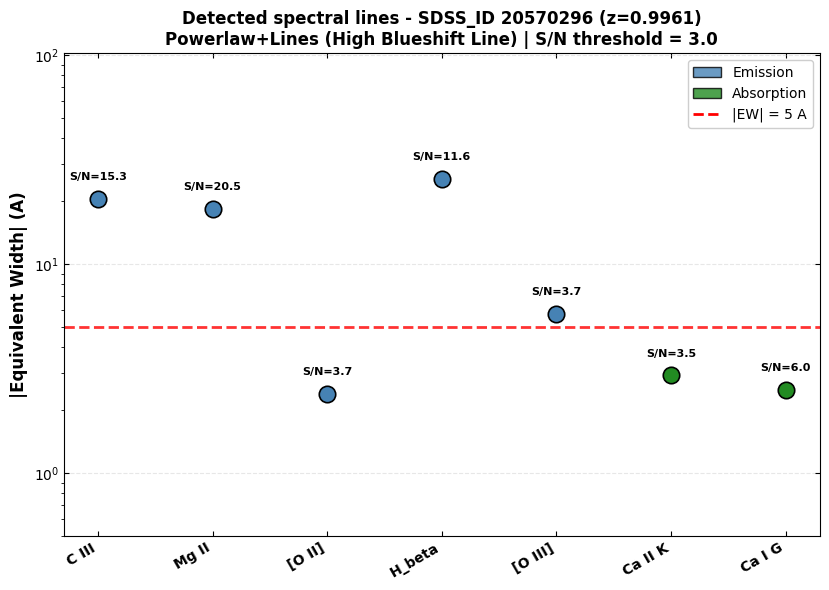

In [29]:
fig = bz_lines(results, min_snr=3.0)

## 12. Redshift posterior

The full p(z) posterior is stored in the cache. Here we plot the global
posterior alongside the best-fit family contribution, and identify
any secondary redshift solutions.

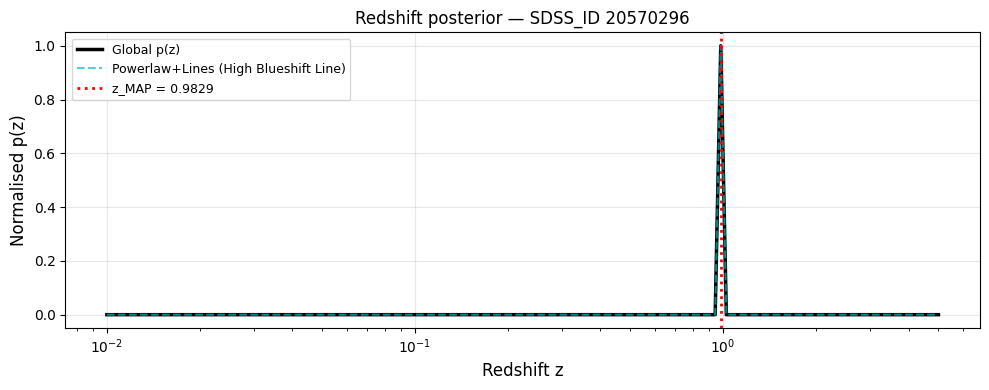


Top redshift solutions:
Rank          z  Rel. height   Note
----------------------------------------
1        0.9829        1.000   primary


In [30]:
pz     = results['pz_results']
z_grid = results['chi2_grids']['z_grid']

family_pz_map = {
    'Powerlaw+Galaxy' : ('pz_galpl',  'r--'),
    'Powerlaw+QSO'    : ('pz_qsopl',  'm--'),
    'Powerlaw+Lines'  : ('pz_linepl', 'c--'),
    'Galaxy'          : ('pz_gal',    'g--'),
    'QSO'             : ('pz_qso',    'b--'),
    'Powerlaw'        : ('pz_pl',     'orange'),
}

best_label = results['lmfit_results']['best_label']
pz_key, style = next(
    ((v[0], v[1]) for k, v in family_pz_map.items() if best_label.startswith(k)),
    ('pz_gal', 'g--')
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(z_grid, normalize_shape(pz['p_total']), 'k-',  lw=2.5, label='Global p(z)')
ax.plot(z_grid, normalize_shape(pz[pz_key]),    style, lw=1.5, alpha=0.7, label=best_label)
ax.axvline(pz['z_map_total'], color='red', ls=':', lw=2,
           label=f"z_MAP = {pz['z_map_total']:.4f}")
ax.set_xscale('log')
ax.set_xlabel('Redshift z', fontsize=12)
ax.set_ylabel('Normalised p(z)', fontsize=12)
ax.set_title(f"Redshift posterior — SDSS_ID {meta['SDSS_ID']}")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Top redshift solutions
peaks = get_redshift_peaks(pz['p_total'], z_grid)
print(f"\nTop redshift solutions:")
print(f"{'Rank':<6} {'z':>8} {'Rel. height':>12}   Note")
print('-' * 40)
for i, (z_peak, height) in enumerate(peaks[:3]):
    note = 'primary' if i == 0 else f'alternative {i}'
    print(f"{i+1:<6} {z_peak:>8.4f} {height:>12.3f}   {note}")

## 13. Raw fit parameters

All best-fit parameters are stored in the cache and can be accessed
directly for custom analysis — useful if you want to build on the
results beyond what the VAC columns provide.

In [31]:
lmfit = results['lmfit_results']

print(f"{'Parameter':<20} {'Value':>12} {'Stderr':>12}")
print('-' * 46)
for name, param in lmfit['best_fit_params']['params'].items():
    val     = param['value']
    err     = param['stderr']
    err_str = f"{err:.4f}" if err is not None else 'N/A'
    print(f"{name:<20} {val:>12.4f} {err_str:>12}")

print(f"\nchi2:        {lmfit['best_fit_params']['chisqr']:.2f}")
print(f"redchi:      {lmfit['best_fit_params']['redchi']:.3f}")
print(f"AICc margin: {lmfit['aicc_margin']:.1f}")
print(f"PL alpha:    {lmfit['pl_alpha']:.4f}")
print(f"PL delta:    {lmfit['pl_delta']:.4f}")

Parameter                   Value       Stderr
----------------------------------------------
scale_line                83.5800       2.1015
A                         40.6766       0.1422
alpha                     -1.2969       0.0318
delta                     -1.2000       0.0793
lam0                    5000.0000       0.0000
z                          0.9961       0.0002

chi2:        3312.51
redchi:      0.728
AICc margin: 49.0
PL alpha:    -1.2969
PL delta:    -1.2000


## 14. Looping over multiple sources

You can load multiple sources and extract parameters in bulk — useful for
building custom population plots or cross-matching with other catalogues.
Here we load all three sources in the test cache.

In [32]:
summary = []

for fname in sorted(cache.list_cached_objects()):
    parts   = fname.replace('.pkl.gz', '').split('_')
    sdss_id = parts[1]
    mjd     = int(parts[2]) if len(parts) > 2 else None
    try:
        res  = cache.load(sdss_id, mjd=mjd)
        lm   = res['lmfit_results']
        m    = res['metadata']
        c    = res['components']

        jet_frac = np.nan
        if lm['best_label'] == 'Powerlaw+Galaxy' and c['galpl_contrib']:
            jet_frac = c['galpl_contrib']['frac_pl']
        elif lm['best_label'].startswith('Powerlaw+QSO') and c['qsopl_contrib']:
            jet_frac = c['qsopl_contrib']['frac_pl']
        elif lm['best_label'].startswith('Powerlaw+Lines') and c['linepl_contrib']:
            jet_frac = c['linepl_contrib']['frac_pl']

        summary.append({'SDSS_ID': sdss_id, 'best_label': lm['best_label'],
                         'z_best': lm['z_best'], 'jet_frac': jet_frac,
                         'sn': m['sn_median']})
    except Exception as e:
        print(f'  Skipped {fname}: {e}')

print(f'\nLoaded {len(summary)} sources')
print(f"\n{'SDSS_ID':<15} {'Model':<20} {'z':>8} {'f_jet':>8} {'S/N':>6}")
print('-' * 60)
for s in summary:
    jf = f"{s['jet_frac']*100:.1f}%" if np.isfinite(s['jet_frac']) else 'N/A'
    print(f"{s['SDSS_ID']:<15} {s['best_label']:<20} {s['z_best']:>8.4f} {jf:>8} {s['sn']:>6.1f}")

Found 3 cached objects in blazar_cache/
Loaded: obj_13362106_59199.pkl.gz
Loaded: obj_15606475_60162.pkl.gz
Loaded: obj_20570296_60027.pkl.gz

Loaded 3 sources

SDSS_ID         Model                       z    f_jet    S/N
------------------------------------------------------------
13362106        Powerlaw+Galaxy        0.6739    29.5%    2.3
15606475        Galaxy                 0.3927      N/A    1.7
20570296        Powerlaw+Lines (High Blueshift Line)   0.9961    90.7%   10.5


## 15. Population plot from cache results

`bz_population` takes a list of cached results and produces a scatter plot
and distribution of any two parameters. This is most informative with the
full 707-source cache — here we demonstrate with the test sources.

Found 3 cached objects in blazar_cache/
Loaded: obj_13362106_59199.pkl.gz
Loaded: obj_15606475_60162.pkl.gz
Loaded: obj_20570296_60027.pkl.gz


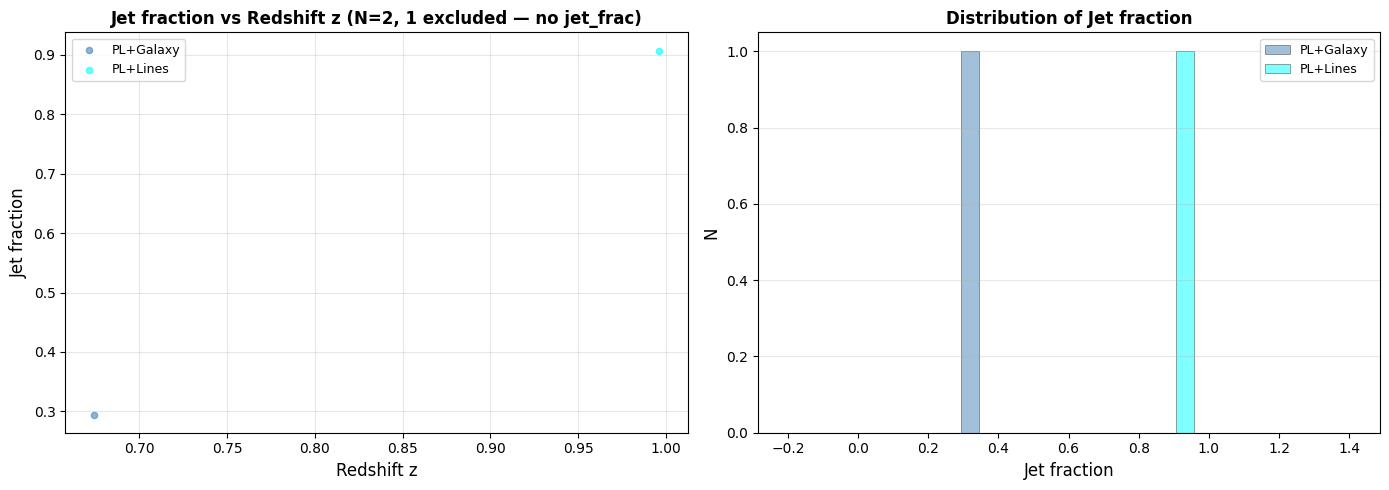

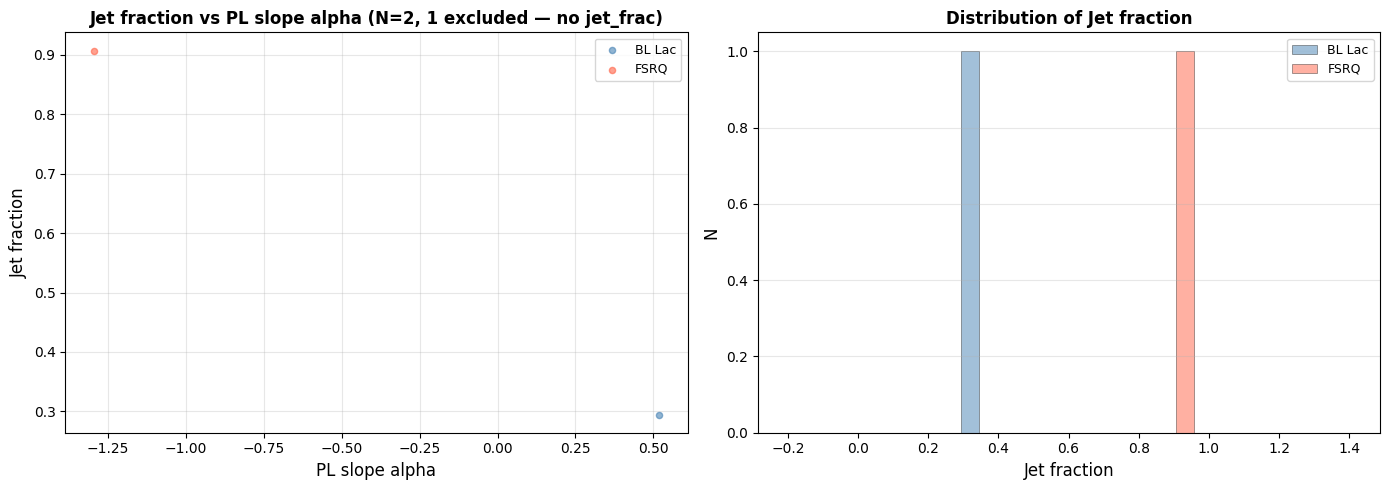

In [33]:
# Load all cached sources into a list
results_list = []
for fname in sorted(cache.list_cached_objects()):
    parts = fname.replace('.pkl.gz', '').split('_')
    try:
        results_list.append(cache.load(parts[1], mjd=int(parts[2])))
    except Exception:
        pass

# Jet fraction vs redshift
fig = bz_population(results_list, x_param='z_best', y_param='jet_frac',
                    color_by='best_label')

# PL alpha vs jet fraction coloured by Fermi class
fig = bz_population(results_list, x_param='pl_alpha', y_param='jet_frac',
                    color_by='fermi_class')